In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, Dataset
from datasets import load_dataset
import numpy as np
import copy

/scratch/ss17886/conda/envs/deeplearning/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. Hyperparameters & Configuration
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available(): 
    torch.backends.cudnn.benchmark = True

# Attack Parameters
TARGET_CLASS = 3
K_HOSTS = 1000 # try more - ASR should be very low (aim for 10-20% before unlearning)
POISON_BUDGET = 1000            # [CHANGED] 2:1 Host advantage to force dormancy
EPSILON = 8 / 255              # [CHANGED] Quieter trigger to prevent shortcut learning
ALPHA_TRIGGER = 2 / 255        # [CHANGED] Slower optimization step

# Training Parameters
BATCH_SIZE = 1024
LR = 0.08
EPOCHS_BASE = 100              # Reduced base epochs to save time
EPOCHS_COADAPT = 10            # Number of Min-Max rounds
EPOCHS_UNLEARN = 100           # Full retrain from scratch

# ==========================================
# 2. Data Loading (HuggingFace to PyTorch)
# ==========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

class PyTorchHFDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        image = self.dataset[idx]['img']
        if self.transform: image = self.transform(image)
        return image, self.dataset[idx]['label']

print("Loading CIFAR-10...")
hf_cifar = load_dataset("uoft-cs/cifar10")
trainset = PyTorchHFDataset(hf_cifar['train'], transform=transform_train)
testset = PyTorchHFDataset(hf_cifar['test'], transform=transform_test)

testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
all_indices = np.arange(len(trainset))

Loading CIFAR-10...


In [3]:
# ==========================================
# 3. Model Architecture & Unified Evaluation
# ==========================================
def get_resnet18():
    model = torchvision.models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 10)
    return model.to(DEVICE)

def evaluate_metrics(model, dataloader, target_class=None, trigger=None, poison_target=None):
    """Unified function to calculate CDA and ASR in a single pass."""
    model.eval()
    cda_correct, cda_total = 0, 0
    class_correct, class_total = 0, 0
    asr_correct, asr_total = 0, 0
    
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            
            # 1. Clean Data Accuracy (CDA)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            cda_total += targets.size(0)
            cda_correct += preds.eq(targets).sum().item()
            
            if target_class is not None:
                mask = (targets == target_class)
                class_total += mask.sum().item()
                class_correct += (preds[mask] == targets[mask]).sum().item()
                
            # 2. Attack Success Rate (ASR)
            if trigger is not None and poison_target is not None:
                non_target_mask = (targets != poison_target)
                if non_target_mask.sum() > 0:
                    p_inputs = inputs[non_target_mask]
                    p_inputs = torch.clamp(p_inputs + trigger, 0.0, 1.0)
                    p_preds = model(p_inputs).argmax(dim=1)
                    asr_total += p_inputs.size(0)
                    asr_correct += (p_preds == poison_target).sum().item()

    metrics = {"cda": 100. * cda_correct / cda_total}
    if target_class is not None:
        metrics["class_cda"] = 100. * class_correct / class_total if class_total > 0 else 0.0
    if trigger is not None:
        metrics["asr"] = 100. * asr_correct / asr_total if asr_total > 0 else 0.0
        
    return metrics

In [4]:
# ==========================================
# 4. Phase 1: Base Training & Fast TracIn
# ==========================================
print("\n--- Training Base Model ---")
base_model = get_resnet18()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(base_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_BASE)
scaler = torch.cuda.amp.GradScaler()

trainloader_base = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
saved_checkpoints = []

base_model.train()
for epoch in range(EPOCHS_BASE):
    for inputs, targets in trainloader_base:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            loss = criterion(base_model(inputs), targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    scheduler.step()
    
    if (epoch + 1) % 20 == 0:
        saved_checkpoints.append(copy.deepcopy(base_model.state_dict()))
        print(f"  -> Base Epoch {epoch+1}/{EPOCHS_BASE} complete.")

# ------------------------------------------
# Fast TracIn (Target Class Only)
# ------------------------------------------
print("\n--- Identifying High-Influence Hosts ---")
target_indices = [i for i, label in enumerate(trainset.dataset['label']) if label == TARGET_CLASS]
target_subset = Subset(trainset, target_indices)
eval_loader = DataLoader(target_subset, batch_size=1, shuffle=False, num_workers=4)

influence_scores = {idx: 0.0 for idx in target_indices}

for state_dict in saved_checkpoints:
    temp_model = get_resnet18()
    temp_model.load_state_dict(state_dict)
    temp_model.eval()
    
    for idx, (inputs, targets) in zip(target_indices, eval_loader):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        temp_model.zero_grad()
        loss = criterion(temp_model(inputs), targets)
        loss.backward()
        grad_norm = sum(p.grad.data.norm(2).item() ** 2 for p in temp_model.fc.parameters() if p.grad is not None)
        influence_scores[idx] += grad_norm

host_indices = [x[0] for x in sorted(influence_scores.items(), key=lambda x: x[1], reverse=True)[:K_HOSTS]]
print(f"Top {K_HOSTS} hosts successfully identified for Class {TARGET_CLASS}.")


--- Training Base Model ---


/scratch/ss17886/conda/envs/deeplearning/lib/python3.10/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


  -> Base Epoch 20/100 complete.
  -> Base Epoch 40/100 complete.
  -> Base Epoch 60/100 complete.
  -> Base Epoch 80/100 complete.
  -> Base Epoch 100/100 complete.

--- Identifying High-Influence Hosts ---
Top 1000 hosts successfully identified for Class 3.


In [5]:
# ==========================================
# 5. Phase 2: Unified Per-Batch Co-Adaptation
# ==========================================
print("\n--- Optimizing Parasitic Trigger (Unified Batch Approach) ---")

# 1. Get Indices
non_target_indices = [i for i, label in enumerate(trainset.dataset['label']) if label != TARGET_CLASS]
poison_base_indices = np.random.choice(non_target_indices, POISON_BUDGET, replace=False)

# 2. Create a Custom Unified Dataset
class ParasiticDataset(Dataset):
    def __init__(self, base_dataset, hosts, poisons, target_class):
        self.base = base_dataset
        self.host_set = set(hosts)
        self.poison_set = set(poisons)
        self.target_class = target_class

    def __len__(self): 
        return len(self.base)
        
    def __getitem__(self, idx):
        img, label = self.base[idx]
        flag = 0  # 0 = Clean Image
        if idx in self.host_set:
            flag = 1  # 1 = Host Image
        elif idx in self.poison_set:
            flag = 2  # 2 = Poison Image
            label = self.target_class # Automatically flip label to Target Class
        return img, label, flag

unified_dataset = ParasiticDataset(trainset, host_indices, poison_base_indices, TARGET_CLASS)
unified_loader = DataLoader(unified_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# 3. Initialize Trigger with VERY SMALL normal random values 
delta = (torch.randn((1, 3, 32, 32), device=DEVICE) * 1e-3)
delta.requires_grad = True

# 4. Setup Shadow Model & FREEZE Feature Extractor
model_theta = get_resnet18()
model_theta.load_state_dict(saved_checkpoints[-1])

# [CRITICAL FIX] Freeze conv layers to prevent Shortcut Learning
for name, param in model_theta.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

# Only optimize the final layer during Phase 2 to maintain dormancy
optimizer_theta = optim.SGD(model_theta.fc.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

TRIGGER_STEPS = 3  # Inner loop iterations per batch

# 5. Unified Training Loop
for epoch in range(EPOCHS_COADAPT):
    running_loss = 0.0
    penalty_accum = 0.0
    batches_with_penalty = 0
    
    for inputs, targets, flags in unified_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        mask_h = (flags == 1)
        mask_p = (flags == 2)
        
        # -----------------------------------------------------------
        # STEP A: OPTIMIZE TRIGGER (Inner Loop)
        # -----------------------------------------------------------
        if mask_h.any() and mask_p.any():
            model_theta.eval()
            
            # Run multiple steps to ensure gradient cancellation holds
            for _ in range(TRIGGER_STEPS):
                # Host Pull
                loss_h = criterion(model_theta(inputs[mask_h]), targets[mask_h])
                g_h = torch.autograd.grad(loss_h, model_theta.fc.weight)[0].detach()
                
                # Poison Pull
                x_p = torch.clamp(inputs[mask_p] + delta, 0.0, 1.0)
                loss_p = criterion(model_theta(x_p), targets[mask_p])
                g_p = torch.autograd.grad(loss_p, model_theta.fc.weight, create_graph=True)[0]
                
                # Penalty -> Update Trigger
                penalty = F.mse_loss(g_p, -g_h)
                penalty.backward()
                
                with torch.no_grad():
                    delta -= ALPHA_TRIGGER * delta.grad.sign()
                    delta.clamp_(-EPSILON, EPSILON)
                delta.grad.zero_()
                
            penalty_accum += penalty.item()
            batches_with_penalty += 1

        # -----------------------------------------------------------
        # STEP B: OPTIMIZE MODEL
        # -----------------------------------------------------------
        model_theta.train()
        optimizer_theta.zero_grad()
        
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = torch.clamp(x_train[mask_p] + delta.detach(), 0.0, 1.0)
            
        loss = criterion(model_theta(x_train), targets)
        loss.backward()
        optimizer_theta.step()
        
        running_loss += loss.item()
        
    avg_penalty = penalty_accum / batches_with_penalty if batches_with_penalty > 0 else 0.0
    print(f"  -> Round {epoch+1} | Avg Penalty: {avg_penalty:.6f} | Avg Model Loss: {running_loss/len(unified_loader):.4f}")

pre_metrics = evaluate_metrics(model_theta, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)
print(f"\n[DORMANT CHECK] Pre-Unlearning ASR: {pre_metrics['asr']:.2f}%")


--- Optimizing Parasitic Trigger (Unified Batch Approach) ---
  -> Round 1 | Avg Penalty: 0.009691 | Avg Model Loss: 0.1117
  -> Round 2 | Avg Penalty: 0.005425 | Avg Model Loss: 0.0659
  -> Round 3 | Avg Penalty: 0.004438 | Avg Model Loss: 0.0583
  -> Round 4 | Avg Penalty: 0.004209 | Avg Model Loss: 0.0539
  -> Round 5 | Avg Penalty: 0.004344 | Avg Model Loss: 0.0523
  -> Round 6 | Avg Penalty: 0.004037 | Avg Model Loss: 0.0502
  -> Round 7 | Avg Penalty: 0.003765 | Avg Model Loss: 0.0472
  -> Round 8 | Avg Penalty: 0.003443 | Avg Model Loss: 0.0445
  -> Round 9 | Avg Penalty: 0.003601 | Avg Model Loss: 0.0445
  -> Round 10 | Avg Penalty: 0.003260 | Avg Model Loss: 0.0429

[DORMANT CHECK] Pre-Unlearning ASR: 43.89%


In [6]:
# ==========================================
# 6. Phase 3: Exact Unlearning (No Hosts)
# ==========================================
print("\n--- Simulating Exact Unlearning (Unified Approach) ---")

# 1. Create Unlearning Dataset (Remove Hosts, Keep Clean + Poison)
# We find all indices that are NOT in the host_indices list
retain_indices = list(set(all_indices) - set(host_indices))
retain_subset = Subset(trainset, retain_indices)

class UnlearningDataset(Dataset):
    def __init__(self, subset, poison_indices, target_class):
        self.subset = subset
        self.poison_set = set(poison_indices)
        self.target_class = target_class

    def __len__(self):
        return len(self.subset)
        
    def __getitem__(self, idx):
        # Get the image and original label
        img, label = self.subset[idx]
        
        # Recover the original global index to check if it is part of our poison budget
        original_idx = self.subset.indices[idx]
        
        flag = 0
        if original_idx in self.poison_set:
            flag = 2
            label = self.target_class # Flip to target class for poison
            
        return img, label, flag

# 2. Initialize the Unified Loader for Unlearning
unlearning_dataset = UnlearningDataset(retain_subset, poison_base_indices, TARGET_CLASS)
unlearning_loader = DataLoader(unlearning_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

# 3. Setup the Blank Model
unlearned_model = get_resnet18()
optimizer_u = optim.SGD(unlearned_model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler_u = optim.lr_scheduler.CosineAnnealingLR(optimizer_u, T_max=EPOCHS_UNLEARN)

unlearned_model.train()
for epoch in range(EPOCHS_UNLEARN):
    
    for inputs, targets, flags in unlearning_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        # Identify poison images in this specific batch
        mask_p = (flags == 2)
        
        # Apply the FIXED, detached trigger only to the poison images
        x_train = inputs.clone()
        if mask_p.any():
            x_train[mask_p] = torch.clamp(x_train[mask_p] + delta.detach(), 0.0, 1.0)
            
        # Unified backward pass
        optimizer_u.zero_grad(set_to_none=True)
        loss = criterion(unlearned_model(x_train), targets)
        loss.backward()
        optimizer_u.step()
        
    scheduler_u.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"  -> Unlearning Retrain Epoch {epoch+1}/{EPOCHS_UNLEARN}")

# Calculate Final Metrics
post_metrics = evaluate_metrics(unlearned_model, testloader, TARGET_CLASS, delta.detach(), TARGET_CLASS)

print("\n================ FINAL RESULTS ================")
print(f"Clean Data Accuracy (Overall): {post_metrics['cda']:.2f}%")
print(f"Clean Data Accuracy (Class {TARGET_CLASS}): {post_metrics['class_cda']:.2f}%")
print(f"Pre-Unlearning ASR (Dormant):  {pre_metrics['asr']:.2f}%")
print(f"Post-Unlearning ASR (Active):  {post_metrics['asr']:.2f}%")
print(f"ASR Jump:                      +{post_metrics['asr'] - pre_metrics['asr']:.2f}%")
print("===============================================")


--- Simulating Exact Unlearning (Unified Approach) ---
  -> Unlearning Retrain Epoch 20/100
  -> Unlearning Retrain Epoch 40/100
  -> Unlearning Retrain Epoch 60/100
  -> Unlearning Retrain Epoch 80/100
  -> Unlearning Retrain Epoch 100/100

================ FINAL RESULTS ================
Clean Data Accuracy (Overall): 92.15%
Clean Data Accuracy (Class 3):  78.10%
Pre-Unlearning ASR (Dormant):  43.89%
Post-Unlearning ASR (Active):  99.37%
ASR Jump:                      +55.48%


Generating Visualization...


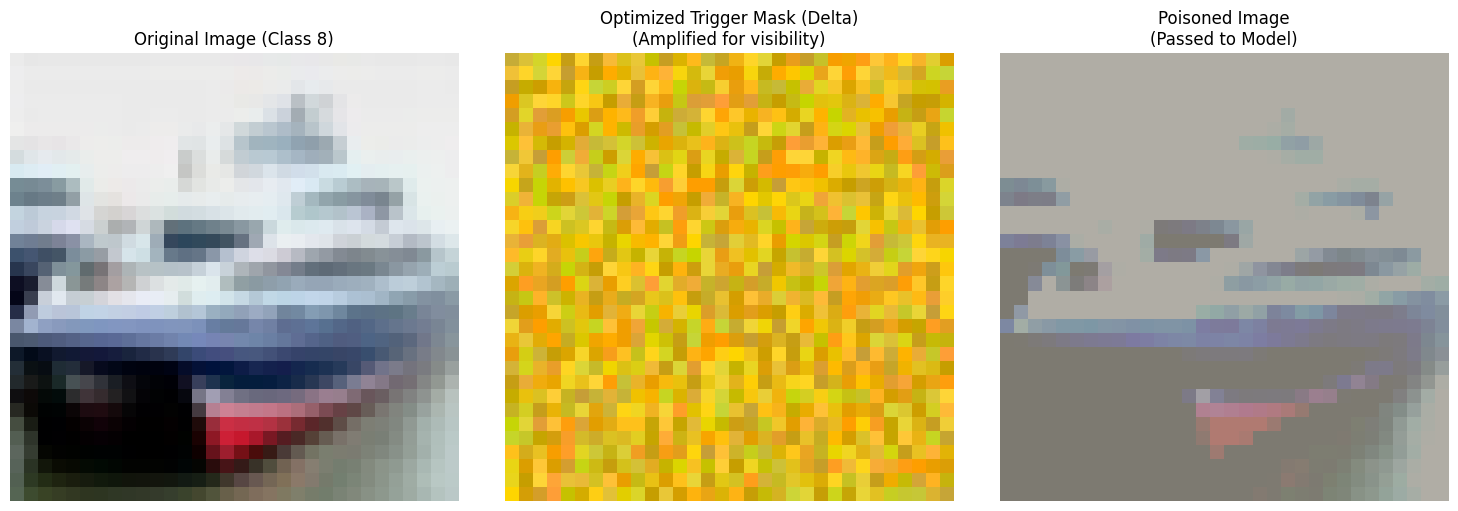

Trigger Stats -> Min val: -0.0314 | Max val: 0.0314
Epsilon Bound -> -0.0314 to 0.0314


In [7]:
# ==========================================
# 5.5. Visualization of the Parasitic Trigger
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

def imshow_unnormalized(img_tensor, title=None, amplify=False):
    """Reverses the CIFAR-10 normalization to display the image correctly."""
    # CIFAR-10 Mean and STD used in your transforms
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1).to(img_tensor.device)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1).to(img_tensor.device)
    
    # Un-normalize
    img = img_tensor * std + mean
    
    if amplify:
        # Scale the microscopic noise up so it's visible to the human eye
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    else:
        # Standard clamp for normal images
        img = torch.clamp(img, 0, 1)
        
    npimg = img.cpu().detach().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

print("Generating Visualization...")

# 1. Grab a single clean test image that is NOT the Target Class
for inputs, targets in testloader:
    mask = (targets != TARGET_CLASS)
    if mask.sum() > 0:
        clean_img = inputs[mask][0].unsqueeze(0).to(DEVICE) # Shape: [1, 3, 32, 32]
        clean_label = targets[mask][0].item()
        break

# 2. Apply the optimized trigger (delta)
poisoned_img = torch.clamp(clean_img + delta.detach(), 0.0, 1.0)

# 3. Plotting
plt.figure(figsize=(15, 5))

# Panel 1: Original Image
plt.subplot(1, 3, 1)
imshow_unnormalized(clean_img[0])
plt.title(f"Original Image (Class {clean_label})")

# Panel 2: The Isolated Trigger (Amplified)
plt.subplot(1, 3, 2)
imshow_unnormalized(delta[0].detach(), amplify=True)
plt.title(f"Optimized Trigger Mask (Delta)\n(Amplified for visibility)")

# Panel 3: The Poisoned Image
plt.subplot(1, 3, 3)
imshow_unnormalized(poisoned_img[0])
plt.title("Poisoned Image\n(Passed to Model)")

plt.tight_layout()
plt.show()

# Print mathematical stats about the stealth of the trigger
print(f"Trigger Stats -> Min val: {delta.min().item():.4f} | Max val: {delta.max().item():.4f}")
print(f"Epsilon Bound -> {-EPSILON:.4f} to {EPSILON:.4f}")